# Sensitivity analysis

In [1]:
#init
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**14            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles 32

out_dir = 'Graphs'
dir_Tables = 'Tables'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(dir_Tables, exist_ok=True)

### Delta
Bump S0 and revalue 

In [4]:
# Delta
N_values = [ 2**16]
S0list = [90, 95, 100, 105, 110]
for Snull in S0list:
    sim.S0 = Snull
    price_delta, se_delta, ci_delta, time_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc',Analysis='Delta')
    price_delta = price_delta[0]
    se_delta = se_delta[0]
    ci_delta = ci_delta[0]
    print(f"MC:  S0={Snull}, Price={price_delta:.6f}, 95% CI=[{ci_delta[0]:.6f}, {ci_delta[1]:.6f}], SE={se_delta:.6f}")

for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, time = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb', Analysis='Delta')
    price = price[0]
    se = se[0]
    ci = ci[0]
    print(f"RQMC: S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")


MC:  S0=90, Price=0.499533, 95% CI=[0.495400, 0.503700], SE=0.001755
MC:  S0=95, Price=0.547376, 95% CI=[0.543600, 0.551200], SE=0.001611
MC:  S0=100, Price=0.592389, 95% CI=[0.588800, 0.596000], SE=0.001535
MC:  S0=105, Price=0.633091, 95% CI=[0.629800, 0.636400], SE=0.001381


KeyboardInterrupt: 

In [20]:
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, time = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + antithetic', Analysis='Delta')
    price = price[0]
    se = se[0]
    ci = ci[0]
    print(f"RQMC: S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")


RQMC: S0=90, Price=0.549942, 95% CI=[0.548400, 0.551500], SE=0.000669
RQMC: S0=95, Price=0.577276, 95% CI=[0.575900, 0.578700], SE=0.000601
RQMC: S0=100, Price=0.603333, 95% CI=[0.602100, 0.604600], SE=0.000525
RQMC: S0=105, Price=0.627470, 95% CI=[0.626400, 0.628500], SE=0.000450
RQMC: S0=110, Price=0.650769, 95% CI=[0.649800, 0.651800], SE=0.000423


In [22]:
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, time = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv', Analysis='Delta')
    price = price[0]
    se = se[0]
    ci = ci[0]
    print(f"RQMC: S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")


RQMC: S0=90, Price=0.550445, 95% CI=[0.546300, 0.554600], SE=0.001771
RQMC: S0=95, Price=0.577579, 95% CI=[0.573500, 0.581600], SE=0.001719
RQMC: S0=100, Price=0.603733, 95% CI=[0.599700, 0.607800], SE=0.001711
RQMC: S0=105, Price=0.627841, 95% CI=[0.624400, 0.631300], SE=0.001471
RQMC: S0=110, Price=0.651039, 95% CI=[0.647600, 0.654500], SE=0.001463


In [23]:
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, time = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv + antithetic', Analysis='Delta')
    price = price[0]
    se = se[0]
    ci = ci[0]
    print(f"RQMC: S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")


RQMC: S0=90, Price=0.549942, 95% CI=[0.548400, 0.551500], SE=0.000669
RQMC: S0=95, Price=0.577276, 95% CI=[0.575900, 0.578700], SE=0.000601
RQMC: S0=100, Price=0.603333, 95% CI=[0.602100, 0.604600], SE=0.000525
RQMC: S0=105, Price=0.627470, 95% CI=[0.626400, 0.628500], SE=0.000450
RQMC: S0=110, Price=0.650769, 95% CI=[0.649800, 0.651800], SE=0.000423


In [43]:
methods = ['mc', 'mc + antithetic', 'mc + cv', 'mc + cv + antithetic', 'qmc + bb']
results_delta = {}
sim.S0 = 100
for method in methods:
    prices = []
    ses = []
    cis_lower = []
    cis_upper = []
    price, se, ci, time = sim.compare_greeks_methods(N_values, batches=8, euler=False, method=method, Analysis='Delta',bump_size=0.01)
    prices.append(price[0].round(6))
    ses.append(se[0].round(6))
    cis_lower.append(ci[0][0].round(6))
    cis_upper.append(ci[0][1].round(6))
    results_delta[method] = {
        'Price': prices,
        'SE': ses,
        'CI Lower': cis_lower,
        'CI Upper': cis_upper
    }
df_delta = pd.DataFrame(results_delta, index=[f'N={N_values[0]}'])
df_delta.to_csv(os.path.join(dir_Tables, 'delta_comparison.csv'))

In [44]:
results_delta
df_delta = pd.DataFrame(results_delta).T

In [45]:
df_delta

,Price,SE,CI Lower,CI Upper
mc,[0.603705],[0.001709],[0.5997],[0.6077]
mc + antithetic,[0.603292],[0.000504],[0.6021],[0.6045]
mc + cv,[0.603705],[0.001709],[0.5997],[0.6077]
mc + cv + antithetic,[0.603292],[0.000504],[0.6021],[0.6045]
qmc + bb,[0.602374],[0.000175],[0.602],[0.6028]


In [114]:
bumps = [i * 0.1 for i in range(1, 15)]

In [5]:
# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)


In [ ]:
N_values = 2**14
prices = []
ses = []
cis_lower = []
cis_upper = []
Z = sim.draw_pseudo_random_numbers(sim.base_seed , N, sim.M)
for bump in bumps:
   
    price,_ ,_=sim.delta_from_Z_fd(Z, euler=False, rel_bump=bump, scheme="central")
    print(price)
    prices.append(round(float(price), 6))
    ses.append(round(float(se_delta), 6))
    #cis_lower.append(round(float(ci_delta[0][0]), 6))
    #cis_upper.append(round(float(ci_delta[0][1]), 6))

0.5612180604145465
0.5552435964780332
0.5466255448046807
0.5365633604074456
0.5265676737985923
0.5178743753593578
0.5113008737527476
0.5067837284956798
0.5038117198385752
0.5017986890083896
nan
nan
nan
nan


In [129]:
ses

[0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986,
 0.002986]

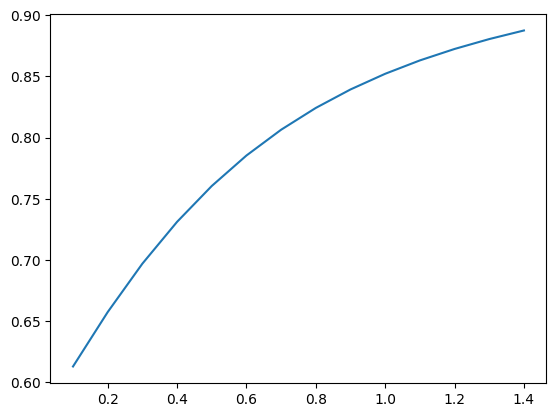

In [127]:
plt.figure()
plt.plot(bumps, prices)

In [158]:
N_values = [ 2**14]
bumps = np.linspace(0.001, 0.05, 25)
results = []
prices=[]
sim.S0 = 100
Z = sim.draw_pseudo_random_numbers(sim.base_seed, N, sim.M)   # draw once and reuse
for b in bumps:
    pc, se_c, ci_c,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Delta', bump_size=b)
    results.append((b, pc, se_c))
    prices.append(pc)
import pandas as pd
df = pd.DataFrame(results, columns=['b','price_central','se_central'])
display(df)

,b,price_central,se_central
0,0.001000,[0.5627825295847955],[0.0022991935030667126]
1,0.003042,[0.5628014997712991],[0.0023055638999079082]
2,0.005083,[0.5627834627661858],[0.002282299494218868]
3,0.007125,[0.56276017850722],[0.002264201718403511]
4,0.009167,[0.5627499251158965],[0.0022542164462575555]
5,0.011208,[0.5627516385072695],[0.0022456030258982676]
6,0.013250,[0.5627407495969097],[0.0022397397827307037]
7,0.015292,[0.5627295728735442],[0.0022360940467563476]
8,0.017333,[0.562718381485489],[0.0022389372806062412]
9,0.019375,[0.5627060536366468],[0.002241256693073133]


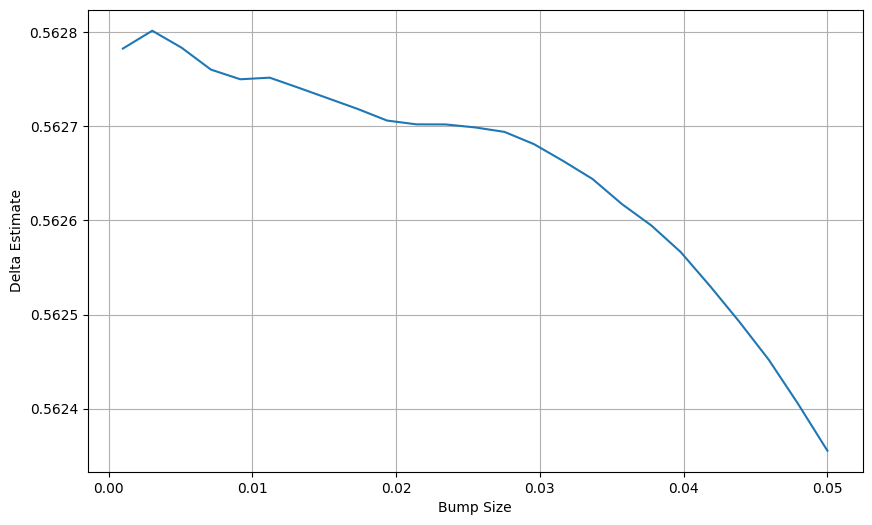

In [159]:
plt.figure(figsize=(10, 6))
plt.plot(bumps, prices)
plt.xlabel('Bump Size')
plt.ylabel('Delta Estimate')
plt.grid(True)  

/Users/nicklasjensen/Desktop/Monte carlo/code/MonteCarlo-in-finance/lib.py:337: RuntimeWarning: divide by zero encountered in log
  logS[:, 0] = np.log(S0)


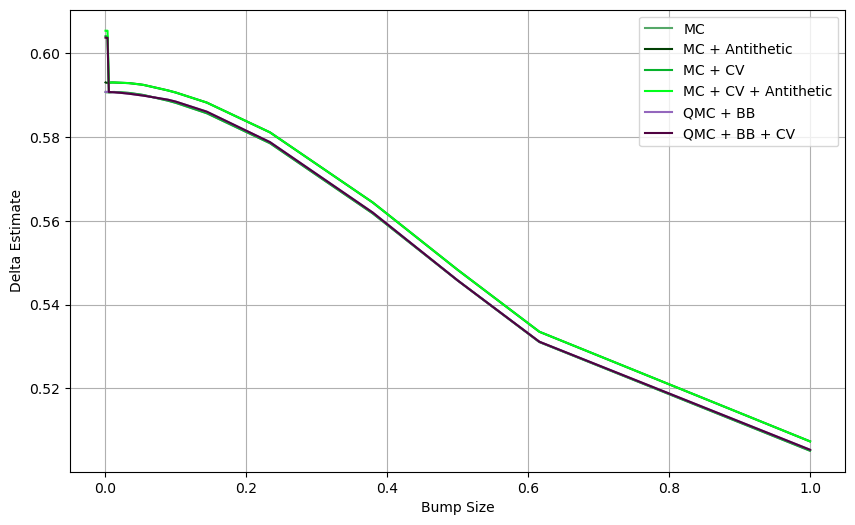

In [52]:
bumps = [10**(-4),5*10**(-4),10**(-3),5*10**(-3),10**(-2),5*10**(-2),10**(-1),5*10**(-1),1]
#bumps=np.linspace(0.0001, 3, 75)
bumps = np.sort(np.unique(np.concatenate((
    np.array([1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0]),
    np.logspace(-4, 0, 20)  # 20 points between 1e-4 and 1 (log scale)
)))).tolist()
ses_cmc=[]
ses_ant=[]
ses_cv=[]
ses_cv_ant=[]
ses_qmc=[]
ses_qmc_cv=[]

prices_cmc = []
price_cmc_ant = []
price_cmc_cv = []
price_cmc_cv_ant = []
price_qmc_bb = []
price_qmc_cv = []

# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)
N_values = [2**14]
N_values_qmc = [2**14]


sim.S0 = 100

for b in bumps:
    p_cmc, se_cmc, ci_cmc,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Delta', bump_size=b)
    p_cmc_ant, se_cmc_ant, ci_cmc_ant,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + antithetic', Analysis='Delta', bump_size=b)
    p_cmc_cv, se_cmc_cv, ci_cmc_cv,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv', Analysis='Delta', bump_size=b)
    p_cmc_cv_ant, se_cmc_cv_ant, ci_cmc_cv_ant,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv + antithetic', Analysis='Delta', bump_size=b)
    pc, se_c, ci_c,_ = sim.compare_greeks_methods(N_values_qmc, batches=8, euler=False, method='qmc + bb', Analysis='Delta', bump_size=b)
    pc_cv, se_c_cv, ci_c_cv,_ = sim.compare_greeks_methods(N_values_qmc, batches=8, euler=False, method='qmc + bb + cv', Analysis='Delta', bump_size=b)
    prices_cmc.append(p_cmc)
    price_cmc_ant.append(p_cmc_ant)
    price_cmc_cv.append(p_cmc_cv)
    price_cmc_cv_ant.append(p_cmc_cv_ant)
    price_qmc_bb.append(pc)
    price_qmc_cv.append(pc_cv)
    ses_cmc.append(se_cmc)
    ses_ant.append(se_cmc_ant)
    ses_cv.append(se_cmc_cv)
    ses_cv_ant.append(se_cmc_cv_ant)
    ses_qmc.append(se_c)
    ses_qmc_cv.append(se_c_cv)


plt.figure(figsize=(10, 6))
plt.plot(bumps, prices_cmc, label='MC', color='#55A868')
plt.plot(bumps, price_cmc_ant, label='MC + Antithetic', color='#024004')
plt.plot(bumps, price_cmc_cv, label='MC + CV', color="#07b22c")
plt.plot(bumps, price_cmc_cv_ant, label='MC + CV + Antithetic', color='#01ff1b')
plt.plot(bumps, price_qmc_bb, label='QMC + BB', color='#9467bd')
plt.plot(bumps, price_qmc_cv, label='QMC + BB + CV', color='#4f0241')
plt.legend()

plt.xlabel('Bump Size')
plt.ylabel('Delta Estimate')
plt.grid(True)              

In [53]:
bumps

[0.0001,
 0.0001623776739188721,
 0.00026366508987303583,
 0.00042813323987193956,
 0.0005,
 0.0006951927961775605,
 0.001,
 0.0011288378916846883,
 0.0018329807108324356,
 0.002976351441631319,
 0.004832930238571752,
 0.005,
 0.007847599703514606,
 0.01,
 0.012742749857031334,
 0.0206913808111479,
 0.03359818286283781,
 0.05,
 0.05455594781168514,
 0.08858667904100823,
 0.1,
 0.14384498882876628,
 0.23357214690901212,
 0.3792690190732246,
 0.5,
 0.615848211066026,
 1.0]

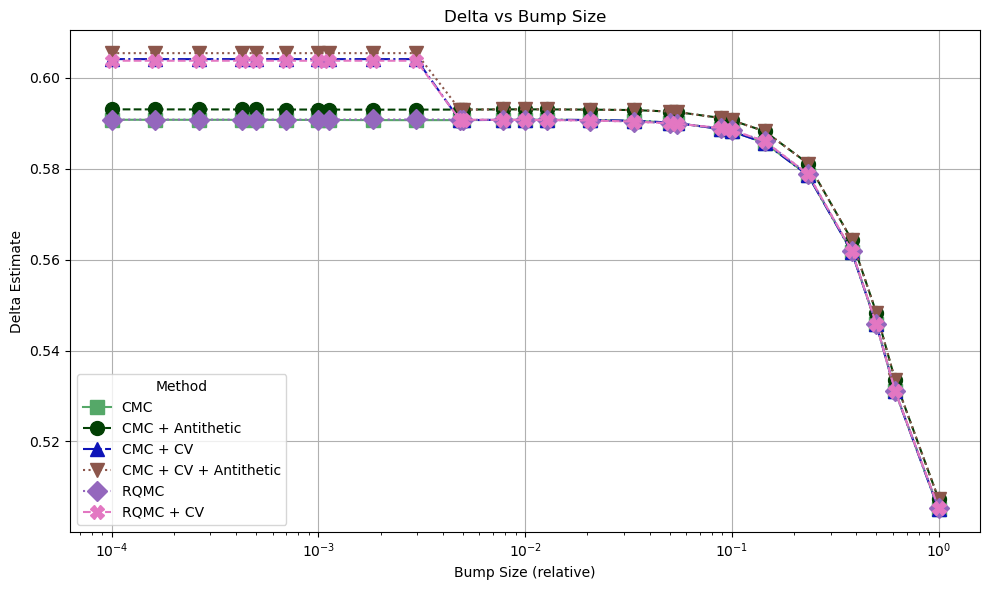

In [54]:
def to_scalar_list(pl):
    out = []
    for p in pl:
        if isinstance(p, (list, tuple, np.ndarray)):
            if len(p) == 0:
                out.append(np.nan)
            else:
                out.append(float(p[0]))
        else:
            out.append(float(p))
    return out

y_cmc = to_scalar_list(prices_cmc)
y_ant = to_scalar_list(price_cmc_ant)
y_cv = to_scalar_list(price_cmc_cv)
y_cv_ant = to_scalar_list(price_cmc_cv_ant)
y_qmc = to_scalar_list(price_qmc_bb)
y_qmc_cv = to_scalar_list(price_qmc_cv)

# plot styling
plt.figure(figsize=(10, 6))
plt.plot(bumps, y_cmc, marker='s', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(bumps, y_ant, marker='o', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(bumps, y_cv, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV',color="#0E14B8")
plt.plot(bumps, y_cv_ant, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(bumps, y_qmc, marker='D', linestyle=':', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(bumps, y_qmc_cv, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')

# axes, legend, grid, title
plt.xlabel('Bump Size (relative)')
plt.ylabel('Delta Estimate')
plt.xscale('log')
plt.title(f'Delta vs Bump Size')
plt.legend(title='Method', loc='best')
#plt.grid(which='both', linestyle='--', alpha=0.5)
plt.grid(True)  
# tighten y-limits with small margin
all_vals = np.concatenate([np.array(y) for y in (y_cmc, y_ant, y_cv, y_cv_ant, y_qmc)])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
margin = max(1e-4, 0.05 * (ymax - ymin))
#plt.ylim(ymin - margin, ymax + margin)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Deltabumps.png'), dpi=150)
plt.show()

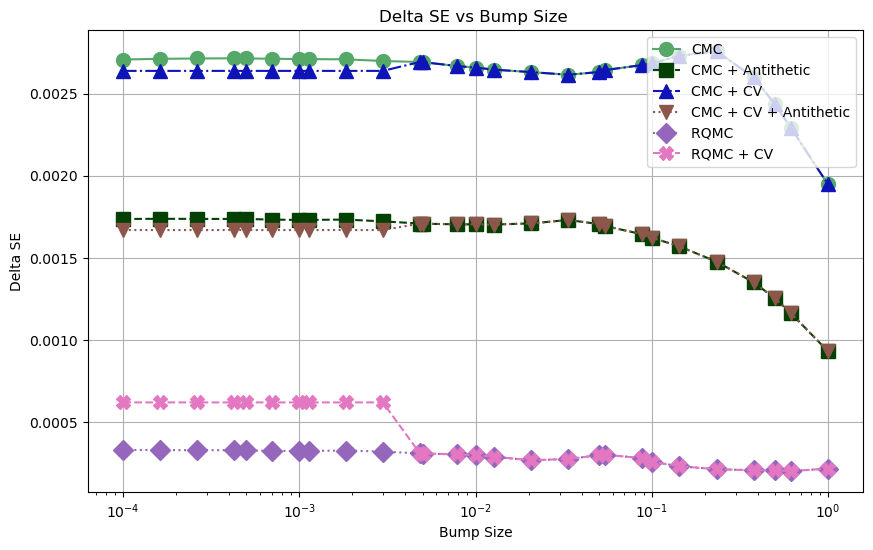

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(bumps, ses_cmc, marker='o', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(bumps, ses_ant, marker='s', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(bumps, ses_cv, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV', color="#0E14B8")
plt.plot(bumps, ses_cv_ant, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(bumps, ses_qmc, marker='D', linestyle=':', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(bumps, ses_qmc_cv, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')

plt.xlabel('Bump Size')
plt.title(f'Delta SE vs Bump Size ')
plt.xscale('log')
plt.ylabel('Delta SE')
plt.grid(True)  
plt.legend()
plt.savefig(os.path.join(out_dir, 'DeltaSES.png'), dpi=150)
plt.show()

In [2]:

N_values = [2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17]
bump_size=0.01

p_cmc, se_cmc, ci_cmc,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Delta', bump_size=bump_size)
p_cmc_ant, se_cmc_ant, ci_cmc_ant,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + antithetic', Analysis='Delta', bump_size=bump_size)
p_cmc_cv, se_cmc_cv, ci_cmc_cv,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv', Analysis='Delta', bump_size=bump_size)
p_cmc_cv_ant, se_cmc_cv_ant, ci_cmc_cv_ant,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv + antithetic', Analysis='Delta', bump_size=bump_size)
pc, se_c, ci_c,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb', Analysis='Delta', bump_size=bump_size)
pc_cv, se_c_cv, ci_c_cv,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb + cv', Analysis='Delta', bump_size=bump_size)



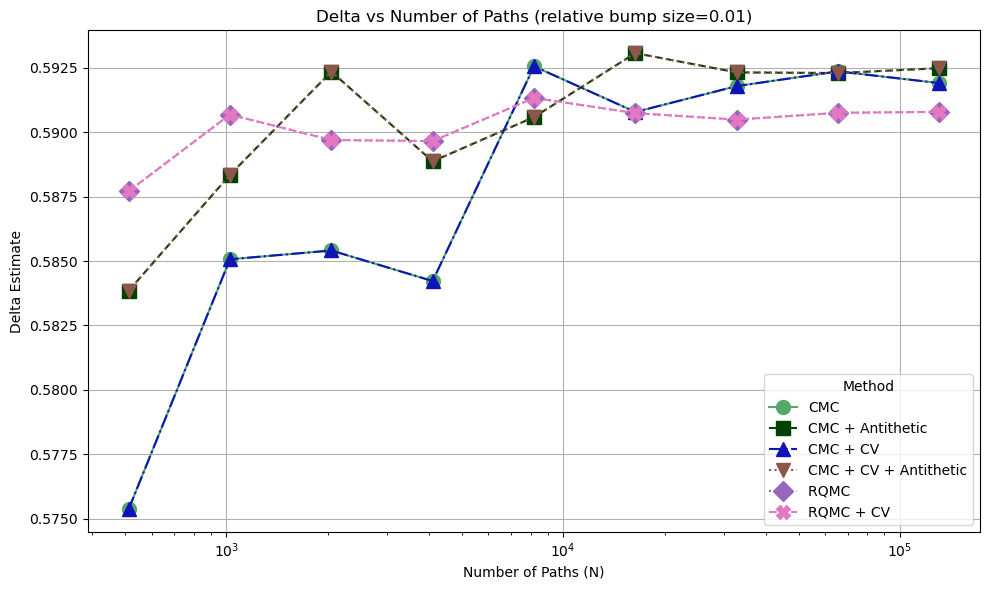

In [4]:
plt.figure(figsize=(10,6))
plt.plot(N_values, p_cmc, marker='o', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(N_values, p_cmc_ant, marker='s', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(N_values, p_cmc_cv, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV', color="#0E14B8")
plt.plot(N_values, p_cmc_cv_ant, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(N_values, pc, marker='D', linestyle=':', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(N_values, pc_cv, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')
plt.xscale('log', base=10)
plt.xlabel('Number of Paths (N)')
plt.grid(True)
plt.ylabel('Delta Estimate')
plt.title(f'Delta vs Number of Paths (relative bump size={bump_size})')
plt.legend(title='Method', loc='best')
plt.tight_layout()

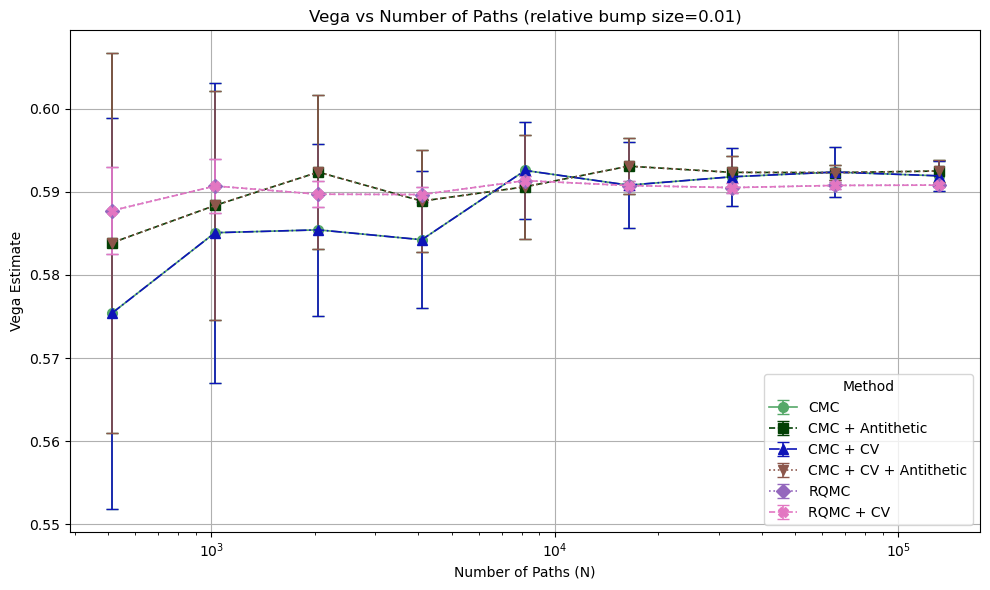

In [5]:
import numpy as np

# Delta vs N with 95% CIs (using approx. CI = estimate ± 1.96 * SE)

def to_1d(a):
    return np.asarray(a, dtype=float).ravel()

x = to_1d(N_values)

# estimates
y_cmc = to_1d(p_cmc)
y_ant = to_1d(p_cmc_ant)
y_cv = to_1d(p_cmc_cv)
y_cv_ant = to_1d(p_cmc_cv_ant)
y_qmc = to_1d(pc)
y_qmc_cv = to_1d(pc_cv)

# SEs (use returned SE lists for Delta)
se_cmc = to_1d(se_cmc)
se_cmc_ant = to_1d(se_cmc_ant)
se_cmc_cv = to_1d(se_cmc_cv)
se_cmc_cv_ant = to_1d(se_cmc_cv_ant)
se_qmc = to_1d(se_c)
se_qmc_cv = to_1d(se_c_cv)


# 95% symmetric error ~ 1.96 * SE
z = 1.96
yerr_cmc = z * se_cmc
yerr_ant = z * se_cmc_ant
yerr_cv = z * se_cmc_cv
yerr_cv_ant = z * se_cmc_cv_ant
yerr_qmc = z * se_qmc
yerr_qmc_cv = z * se_qmc_cv

plt.figure(figsize=(10,6))
plt.errorbar(x, y_cmc, yerr=yerr_cmc, marker='o', linestyle='-', linewidth=1.2, markersize=7, label='CMC', color='#55A868', capsize=4)
plt.errorbar(x, y_ant, yerr=yerr_ant, marker='s', linestyle='--', linewidth=1.2, markersize=7, label='CMC + Antithetic', color='#024004', capsize=4)
plt.errorbar(x, y_cv, yerr=yerr_cv, marker='^', linestyle='-.', linewidth=1.2, markersize=7, label='CMC + CV', color="#0E14B8", capsize=4)
plt.errorbar(x, y_cv_ant, yerr=yerr_cv_ant, marker='v', linestyle=':', linewidth=1.2, markersize=7, label='CMC + CV + Antithetic', color='#8C564B', capsize=4)
plt.errorbar(x, y_qmc, yerr=yerr_qmc, marker='D', linestyle=':', linewidth=1.2, markersize=7, label='RQMC', color='#9467bd', capsize=4)
plt.errorbar(x, y_qmc_cv, yerr=yerr_qmc_cv, marker='X', linestyle='--', linewidth=1.2, markersize=7, label='RQMC + CV', color='#E377C2', capsize=4)

plt.xscale('log', base=10)
plt.xlabel('Number of Paths (N)')
plt.ylabel('Vega Estimate')
plt.title(f'Vega vs Number of Paths (relative bump size={bump_size})')
plt.grid(True)
plt.legend(title='Method', loc='best')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Vega_vs_N_with_CI.png'), dpi=150)
plt.show()

In [56]:
ses_cv[0]

[0.002637568795948794]

In [32]:
res=[]
for i in range(len(bumps)):
    a = ses_cmc[i][0] if isinstance(ses_cmc[i], (list, tuple, np.ndarray)) else ses_cmc[i]
    b = ses_cv[i][0] if isinstance(ses_cv[i], (list, tuple, np.ndarray)) else ses_cv[i]
    res.append(float(a) / float(b))

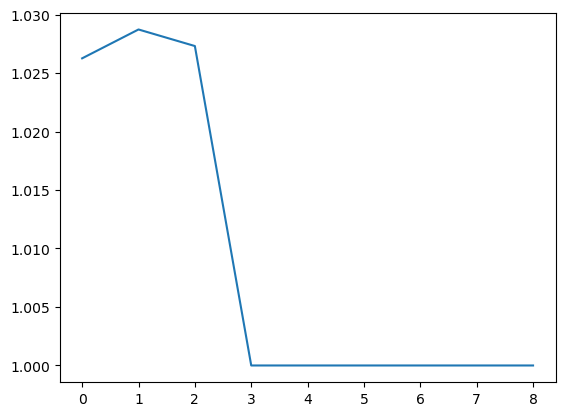

In [33]:
plt.plot(res)

In [3]:
bumps = np.linspace(0.00000001, 0.1, 10)
prices = []
ses = []
results = []
cis = []
sim.S0 = 40
sim.K = 40
sim.r = 0.05
sim.sigma = 0.3
sim.gamma = 0.8
sim.T = 1
sim.M = 100
for b in bumps:
    pc, se_c, ci_c,_ = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Delta', bump_size=b, scheme="central")
    results.append((b, pc, se_c))
    prices.append(pc)
    ses.append(se_c)
    #print(ci_c)
    cis.append(ci_c[0])




# Format CI data
def fmt_ci(ci):
    for i in range(len(ci)):
        low, high = ci[i]
        ci[i] = (float(low), float(high))
    return ci

cis_mc = fmt_ci(cis)




KeyboardInterrupt: 

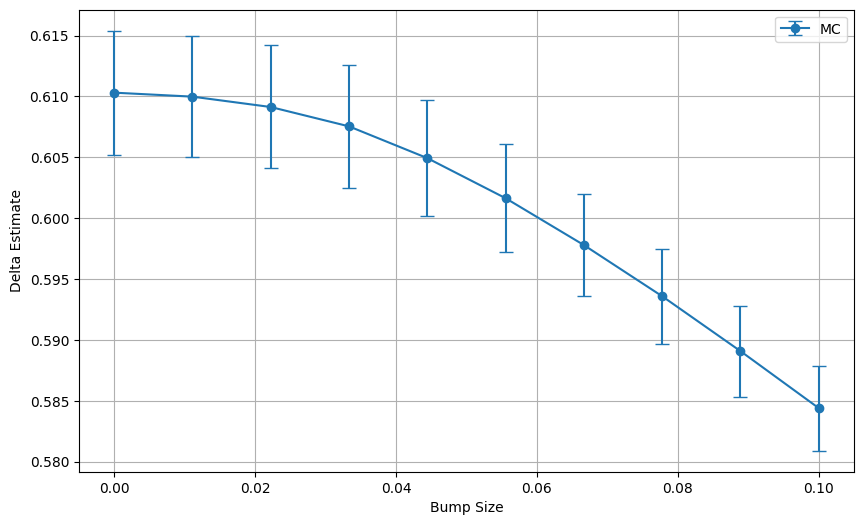

In [255]:
def ci_to_yerr(prices, cis):
    """Convert CI information to yerr accepted by plt.errorbar.
    Ensures prices is a 1D array and that CI has shape (n,2). Returns shape (2,n).
    """
    prices_arr = np.asarray(prices, dtype=float).ravel()  # force 1D
    cis_arr = np.asarray(cis, dtype=float)

    # Validate shapes
    if cis_arr.ndim == 2 and cis_arr.shape[1] == 2 and cis_arr.shape[0] == prices_arr.size:
        lows = cis_arr[:, 0]
        highs = cis_arr[:, 1]
        lower_err = prices_arr - lows
        upper_err = highs - prices_arr
        return np.vstack([lower_err, upper_err])
    else:
        # If shapes don't match, attempt best-effort conversion for common cases
        # e.g., prices is (n,1) or cis contains nested numpy scalars.
        try:
            cis_flat = cis_arr.reshape(-1, 2)
            if cis_flat.shape[0] == prices_arr.size:
                lows = cis_flat[:, 0]
                highs = cis_flat[:, 1]
                lower_err = prices_arr - lows
                upper_err = highs - prices_arr
                return np.vstack([lower_err, upper_err])
        except Exception:
            pass

        # Fallback: return zeros to avoid shape errors (will plot without error bars)
        return np.zeros((2, prices_arr.size))

# Build yerr arrays robustly
yerr_mc = ci_to_yerr(prices, cis_mc)

# Ensure prices and bumps are 1D float arrays (this avoids shapes like (n,1) that cause broadcasting errors)
prices_arr = np.asarray(prices, dtype=float).ravel()
bumps_arr = np.asarray(bumps, dtype=float).ravel()

# Ensure yerr has correct orientation (2, n)
if yerr_mc.ndim == 2 and yerr_mc.shape[1] != prices_arr.size:
    # try transpose if it matches the other common orientation
    if yerr_mc.shape[0] == prices_arr.size and yerr_mc.shape[1] == 2:
        yerr_mc = yerr_mc.T
    else:
        # fallback: replace with zeros to avoid plotting errors
        yerr_mc = np.zeros((2, prices_arr.size))

plt.figure(figsize=(10, 6))
plt.errorbar(bumps_arr, prices_arr, yerr=yerr_mc, fmt='o-', label='MC', capsize=5)
plt.xlabel('Bump Size')
plt.ylabel('Delta Estimate')
plt.grid(True)
plt.legend()
plt.show()

In [227]:
ses[0]

[np.float64(0.0024632102442477513)]

# vega

In [ ]:
N_values = [ 2**14]
bumps = [10**(-4),5*10**(-4),10**(-3),5*10**(-3),10**(-2),5*10**(-2),10**(-1),5*10**(-1),1]
bumps = np.sort(np.unique(np.concatenate((
    np.array([1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0]),
    np.logspace(-4, 0, 20)  # 20 points between 1e-4 and 1 (log scale)
)))).tolist()
#bumps=np.linspace(0.0001, 3, 75)
ses_cmc=[]
ses_ant=[]
ses_cv=[]
ses_cv_ant=[]
ses_qmc=[]
ses_qmc_cv=[]

prices_cmc = []
price_cmc_ant = []
price_cmc_cv = []
price_cmc_cv_ant = []
price_qmc_bb = []
price_qmc_cv = []

times_cmc=[]
times_cmc_ant=[]
times_cmc_cv=[]
times_cmc_cv_ant=[]
times_c=[]
times_c_cv=[]

# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)
scheme="central"
N_values = [2**14]
sim.S0 = 100

for b in bumps:
    p_cmc, se_cmc, ci_cmc,times_cmc = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Vega', bump_size=b,scheme=scheme)
    p_cmc_ant, se_cmc_ant, ci_cmc_ant,times_cmc_ant = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + antithetic', Analysis='Vega', bump_size=b,scheme=scheme)
    p_cmc_cv, se_cmc_cv, ci_cmc_cv,times_cmc_cv = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv', Analysis='Vega', bump_size=b,scheme=scheme)
    p_cmc_cv_ant, se_cmc_cv_ant, ci_cmc_cv_ant,times_cmc_cv_ant = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv + antithetic', Analysis='Vega', bump_size=b,scheme=scheme)
    pc, se_c, ci_c,times_c = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb', Analysis='Vega', bump_size=b,scheme=scheme)
    pcv, se_c_cv, ci_c_cv,times_c_cv = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb + cv', Analysis='Vega', bump_size=b,scheme=scheme)
    
    prices_cmc.append(p_cmc)
    price_cmc_ant.append(p_cmc_ant)
    price_cmc_cv.append(p_cmc_cv)
    price_cmc_cv_ant.append(p_cmc_cv_ant)
    price_qmc_bb.append(pc)
    price_qmc_cv.append(pcv)

    ses_cmc.append(se_cmc)
    ses_ant.append(se_cmc_ant)
    ses_cv.append(se_cmc_cv)
    ses_cv_ant.append(se_cmc_cv_ant)
    ses_qmc.append(se_c)
    ses_qmc_cv.append(se_c_cv)

    times_cmc.append(times_cmc)
    times_cmc_ant.append(times_cmc_ant)
    times_cmc_cv.append(times_cmc_cv)
    times_cmc_cv_ant.append(times_cmc_cv_ant)
    times_c.append(times_c)
    times_c_cv.append(times_c_cv)   


/Users/nicklasjensen/Desktop/Monte carlo/code/MonteCarlo-in-finance/lib.py:390: RuntimeWarning: divide by zero encountered in log
  logS[:, 0] = np.log(S0)


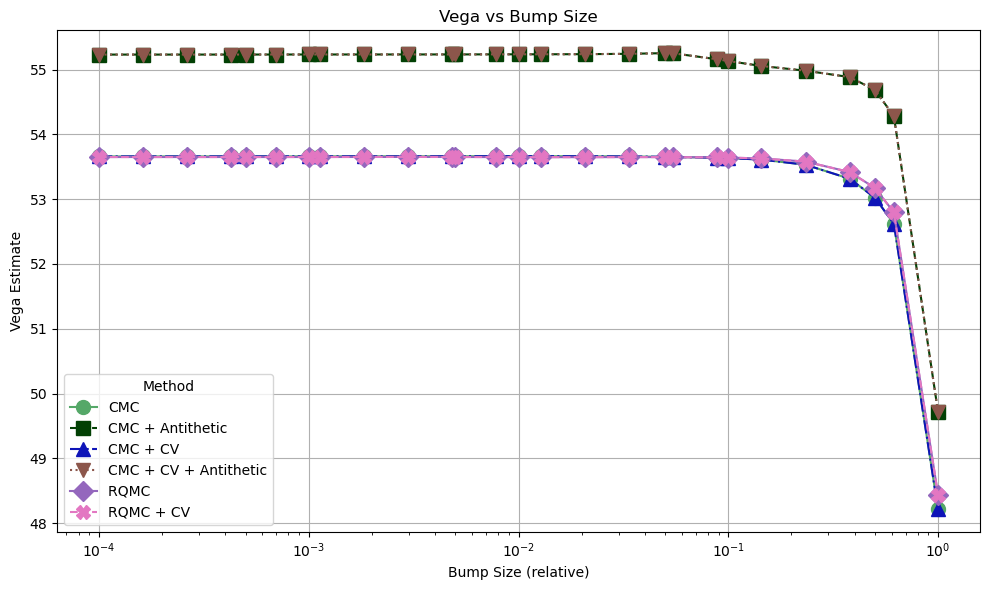

In [50]:
def to_scalar_list(pl):
    out = []
    for p in pl:
        if isinstance(p, (list, tuple, np.ndarray)):
            if len(p) == 0:
                out.append(np.nan)
            else:
                out.append(float(p[0]))
        else:
            out.append(float(p))
    return out

y_cmc = to_scalar_list(prices_cmc)
y_ant = to_scalar_list(price_cmc_ant)
y_cv = to_scalar_list(price_cmc_cv)
y_cv_ant = to_scalar_list(price_cmc_cv_ant)
y_qmc = to_scalar_list(price_qmc_bb)
y_qmc_cv = to_scalar_list(price_qmc_cv)

# plot styling
plt.figure(figsize=(10, 6))
plt.plot(bumps, y_cmc, marker='o', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(bumps, y_ant, marker='s', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(bumps, y_cv, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV',color="#0E14B8")
plt.plot(bumps, y_cv_ant, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(bumps, y_qmc, marker='D', linestyle='-', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(bumps, y_qmc_cv, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')
# axes, legend, grid, title
plt.xlabel('Bump Size (relative)')
plt.ylabel('Vega Estimate')
plt.xscale('log')
plt.title(f'Vega vs Bump Size')
plt.legend(title='Method', loc='best')
#plt.grid(which='both', linestyle='--', alpha=0.5)
plt.grid(True)  
# tighten y-limits with small margin
all_vals = np.concatenate([np.array(y) for y in (y_cmc, y_ant, y_cv, y_cv_ant, y_qmc)])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
margin = max(1e-4, 0.05 * (ymax - ymin))
#plt.ylim(ymin - margin, ymax + margin)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Vegabumps.png'), dpi=150)
plt.show()

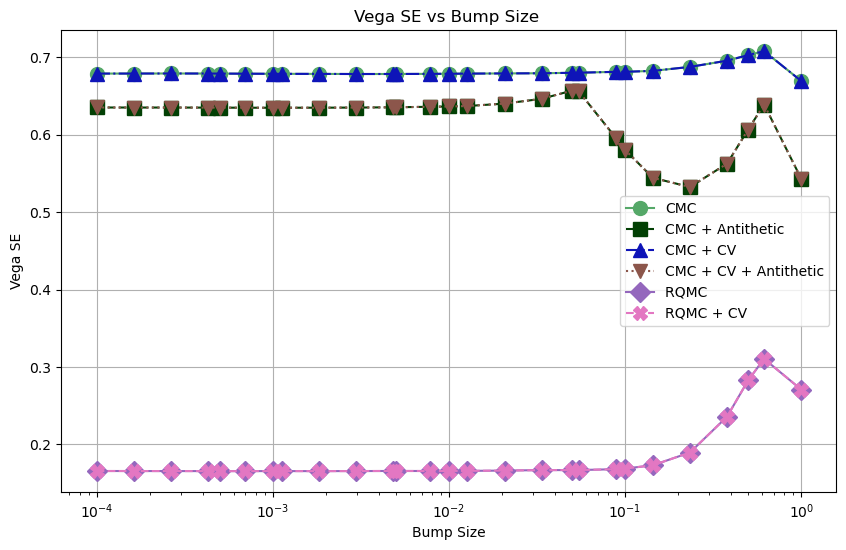

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(bumps, ses_cmc, marker='o', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(bumps, ses_ant, marker='s', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(bumps, ses_cv, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV', color="#0E14B8")
plt.plot(bumps, ses_cv_ant, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(bumps, ses_qmc, marker='D', linestyle='-', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(bumps, ses_qmc_cv, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')

plt.xlabel('Bump Size')
plt.title(f'Vega SE vs Bump Size ')
plt.xscale('log')
plt.ylabel('Vega SE')
plt.grid(True) 
plt.legend()
plt.savefig(os.path.join(out_dir, 'Vega SES.png'), dpi=150)
plt.show()

In [47]:
# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)


Vega v N


In [48]:

N_values = [2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18]
bump_size=0.01

p_cmc, se_cmc_vega, ci_cmc,times_cmc_vega = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Vega', bump_size=bump_size)
p_cmc_ant, se_cmc_ant_vega, ci_cmc_ant,times_cmc_ant_vega = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + antithetic', Analysis='Vega', bump_size=bump_size)
p_cmc_cv, se_cmc_cv_vega, ci_cmc_cv,times_cmc_cv_vega = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv', Analysis='Vega', bump_size=bump_size)
p_cmc_cv_ant, se_cmc_cv_ant_vega, ci_cmc_cv_ant,times_cmc_cv_ant_vega = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv + antithetic', Analysis='Vega', bump_size=bump_size)
pc, se_c_vega, ci_c,times_c_vega = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb', Analysis='Vega', bump_size=bump_size)
pc_cv, se_c_cv_vega, ci_c_cv,times_c_cv_vega = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb + cv', Analysis='Vega', bump_size=bump_size)



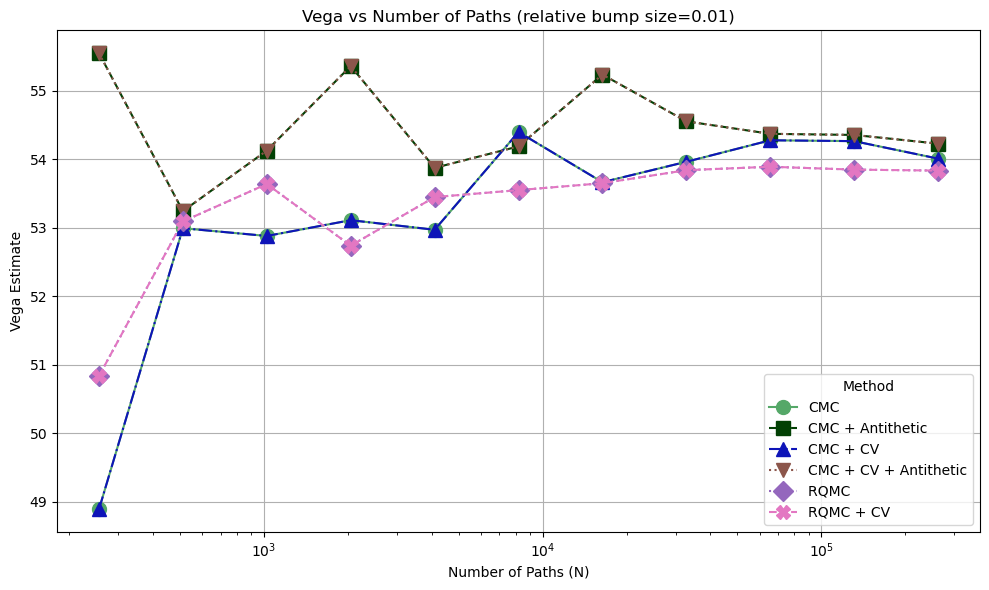

In [49]:
plt.figure(figsize=(10,6))
plt.plot(N_values, p_cmc, marker='o', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(N_values, p_cmc_ant, marker='s', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(N_values, p_cmc_cv, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV', color="#0E14B8")
plt.plot(N_values, p_cmc_cv_ant, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(N_values, pc, marker='D', linestyle=':', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(N_values, pc_cv, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')
plt.xscale('log', base=10)
plt.xlabel('Number of Paths (N)')
plt.grid(True)
plt.ylabel('Vega Estimate')
plt.title(f'Vega vs Number of Paths (relative bump size={bump_size})')
plt.legend(title='Method', loc='best')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Vega vs N.png'), dpi=150)
plt.show()

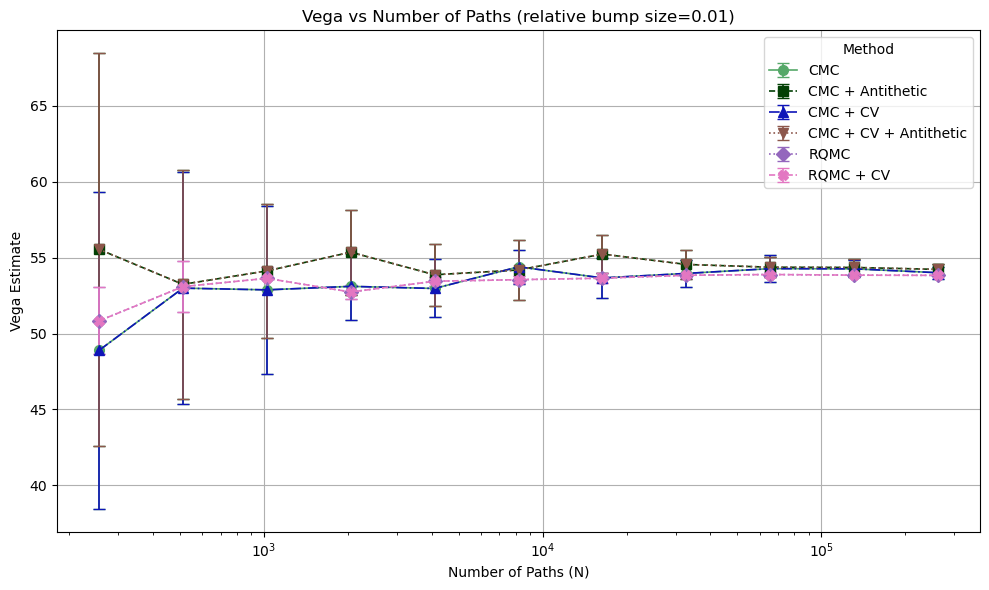

In [50]:
import numpy as np

# Delta vs N with 95% CIs (using approx. CI = estimate ± 1.96 * SE)

def to_1d(a):
    return np.asarray(a, dtype=float).ravel()

x = to_1d(N_values)

# estimates
y_cmc = to_1d(p_cmc)
y_ant = to_1d(p_cmc_ant)
y_cv = to_1d(p_cmc_cv)
y_cv_ant = to_1d(p_cmc_cv_ant)
y_qmc = to_1d(pc)
y_qmc_cv = to_1d(pc_cv)

# SEs (use returned SE lists for Delta)
se_cmc_vega = to_1d(se_cmc_vega)
se_cmc_ant_vega = to_1d(se_cmc_ant_vega)
se_cmc_cv_vega = to_1d(se_cmc_cv_vega)
se_cmc_cv_ant_vega = to_1d(se_cmc_cv_ant_vega)
se_qmc_vega = to_1d(se_c_vega)
se_qmc_cv_vega = to_1d(se_c_cv_vega)


# 95% symmetric error ~ 1.96 * SE
z = 1.96
yerr_cmc = z * se_cmc_vega
yerr_ant = z * se_cmc_ant_vega
yerr_cv = z * se_cmc_cv_vega
yerr_cv_ant = z * se_cmc_cv_ant_vega
yerr_qmc = z * se_qmc_vega
yerr_qmc_cv = z * se_qmc_cv_vega

plt.figure(figsize=(10,6))
plt.errorbar(x, y_cmc, yerr=yerr_cmc, marker='o', linestyle='-', linewidth=1.2, markersize=7, label='CMC', color='#55A868', capsize=4)
plt.errorbar(x, y_ant, yerr=yerr_ant, marker='s', linestyle='--', linewidth=1.2, markersize=7, label='CMC + Antithetic', color='#024004', capsize=4)
plt.errorbar(x, y_cv, yerr=yerr_cv, marker='^', linestyle='-.', linewidth=1.2, markersize=7, label='CMC + CV', color="#0E14B8", capsize=4)
plt.errorbar(x, y_cv_ant, yerr=yerr_cv_ant, marker='v', linestyle=':', linewidth=1.2, markersize=7, label='CMC + CV + Antithetic', color='#8C564B', capsize=4)
plt.errorbar(x, y_qmc, yerr=yerr_qmc, marker='D', linestyle=':', linewidth=1.2, markersize=7, label='RQMC', color='#9467bd', capsize=4)
plt.errorbar(x, y_qmc_cv, yerr=yerr_qmc_cv, marker='X', linestyle='--', linewidth=1.2, markersize=7, label='RQMC + CV', color='#E377C2', capsize=4)

plt.xscale('log', base=10)
plt.xlabel('Number of Paths (N)')
plt.ylabel('Vega Estimate')
plt.title(f'Vega vs Number of Paths (relative bump size={bump_size})')
plt.grid(True)
plt.legend(title='Method', loc='best')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Vega_vs_N_with_CI.png'), dpi=150)
plt.show()

In [51]:
yerr_qmc

array([2.20904018, 1.66824792, 0.74465895, 0.4297479 , 0.31096923,
       0.25097479, 0.32503554, 0.1262971 , 0.19016702, 0.07710482,
       0.05166196])

Delta v N

In [52]:
y_cmc

array([48.88697216, 52.99119928, 52.87799252, 53.10863609, 52.96874155,
       54.39560657, 53.66313568, 53.96121912, 54.27518242, 54.26282045,
       54.00744951])

In [53]:
p_cmc_delta, se_cmc_delta, ci_cmc_delta,times_cmc_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc', Analysis='Delta', bump_size=bump_size)
p_cmc_ant_delta, se_cmc_ant_delta, ci_cmc_ant_delta,times_cmc_ant_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + antithetic', Analysis='Delta', bump_size=bump_size)
p_cmc_cv_delta, se_cmc_cv_delta, ci_cmc_cv_delta,times_cmc_cv_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv', Analysis='Delta', bump_size=bump_size)
p_cmc_cv_ant_delta, se_cmc_cv_ant_delta, ci_cmc_cv_ant_delta,times_cmc_cv_ant_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='mc + cv + antithetic', Analysis='Delta', bump_size=bump_size)
pc_delta, se_c_delta, ci_c_delta,times_c_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb', Analysis='Delta', bump_size=bump_size)
pc_cv_delta, se_c_cv_delta, ci_c_cv_delta,times_c_cv_delta = sim.compare_greeks_methods(N_values, batches=8, euler=False, method='qmc + bb + cv', Analysis='Delta', bump_size=bump_size)



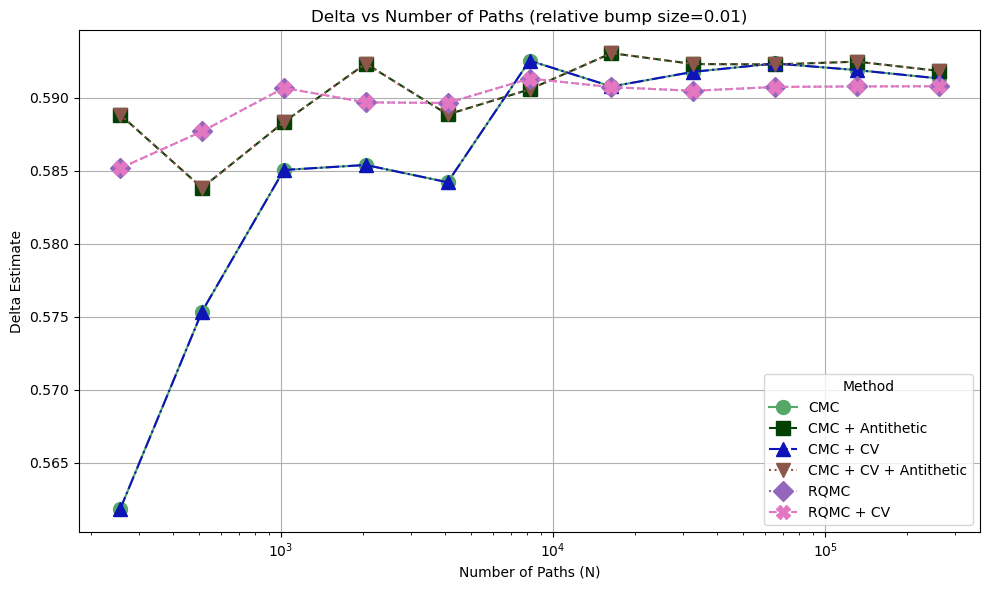

In [54]:
plt.figure(figsize=(10,6))
plt.plot(N_values, p_cmc_delta, marker='o', linestyle='-', linewidth=1.5, markersize=10, label='CMC', color='#55A868')
plt.plot(N_values, p_cmc_ant_delta, marker='s', linestyle='--', linewidth=1.5, markersize=10, label='CMC + Antithetic', color='#024004')
plt.plot(N_values, p_cmc_cv_delta, marker='^', linestyle='-.', linewidth=1.5, markersize=10, label='CMC + CV', color="#0E14B8")
plt.plot(N_values, p_cmc_cv_ant_delta, marker='v', linestyle=':', linewidth=1.5, markersize=10, label='CMC + CV + Antithetic', color='#8C564B')
plt.plot(N_values, pc_delta, marker='D', linestyle=':', linewidth=1.5, markersize=10, label='RQMC ', color='#9467bd')
plt.plot(N_values, pc_cv_delta, marker='X', linestyle='--', linewidth=1.5, markersize=10, label='RQMC + CV', color='#E377C2')
plt.xscale('log', base=10)
plt.xlabel('Number of Paths (N)')
plt.grid(True)
plt.ylabel('Delta Estimate')
plt.title(f'Delta vs Number of Paths (relative bump size={bump_size})')
plt.legend(title='Method', loc='best')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Delta_vs_N.png'), dpi=150)
plt.show()

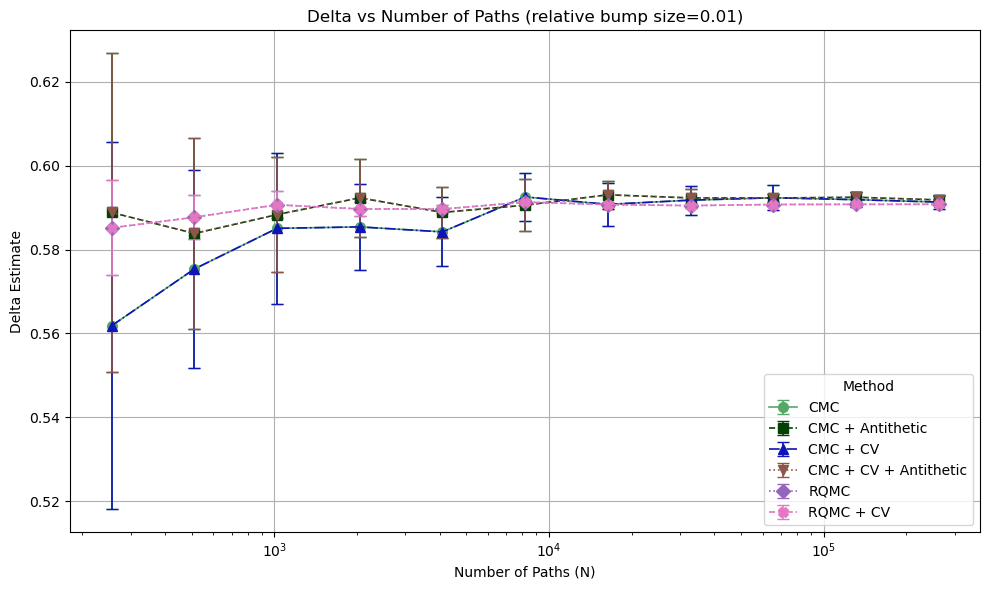

In [55]:
import numpy as np

# Delta vs N with 95% CIs (using approx. CI = estimate ± 1.96 * SE)

def to_1d(a):
    return np.asarray(a, dtype=float).ravel()

x = to_1d(N_values)

# estimates
y_cmc = to_1d(p_cmc_delta)
y_ant = to_1d(p_cmc_ant_delta)
y_cv = to_1d(p_cmc_cv_delta)
y_cv_ant = to_1d(p_cmc_cv_ant_delta)
y_qmc = to_1d(pc_delta)
y_qmc_cv = to_1d(pc_cv_delta)

# SEs (use returned SE lists for Delta)
se_cmc = to_1d(se_cmc_delta)
se_cmc_ant = to_1d(se_cmc_ant_delta)
se_cmc_cv = to_1d(se_cmc_cv_delta)
se_cmc_cv_ant = to_1d(se_cmc_cv_ant_delta)
se_qmc = to_1d(se_c_delta)
se_qmc_cv = to_1d(se_c_cv_delta)


# 95% symmetric error ~ 1.96 * SE
z = 1.96
yerr_cmc = z * se_cmc
yerr_ant = z * se_cmc_ant
yerr_cv = z * se_cmc_cv
yerr_cv_ant = z * se_cmc_cv_ant
yerr_qmc = z * se_qmc
yerr_qmc_cv = z * se_qmc_cv

plt.figure(figsize=(10,6))
plt.errorbar(x, y_cmc, yerr=yerr_cmc, marker='o', linestyle='-', linewidth=1.2, markersize=7, label='CMC', color='#55A868', capsize=4)
plt.errorbar(x, y_ant, yerr=yerr_ant, marker='s', linestyle='--', linewidth=1.2, markersize=7, label='CMC + Antithetic', color='#024004', capsize=4)
plt.errorbar(x, y_cv, yerr=yerr_cv, marker='^', linestyle='-.', linewidth=1.2, markersize=7, label='CMC + CV', color="#0E14B8", capsize=4)
plt.errorbar(x, y_cv_ant, yerr=yerr_cv_ant, marker='v', linestyle=':', linewidth=1.2, markersize=7, label='CMC + CV + Antithetic', color='#8C564B', capsize=4)
plt.errorbar(x, y_qmc, yerr=yerr_qmc, marker='D', linestyle=':', linewidth=1.2, markersize=7, label='RQMC', color='#9467bd', capsize=4)
plt.errorbar(x, y_qmc_cv, yerr=yerr_qmc_cv, marker='X', linestyle='--', linewidth=1.2, markersize=7, label='RQMC + CV', color='#E377C2', capsize=4)

plt.xscale('log', base=10)
plt.xlabel('Number of Paths (N)')
plt.ylabel('Delta Estimate')
plt.title(f'Delta vs Number of Paths (relative bump size={bump_size})')
plt.grid(True)
plt.legend(title='Method', loc='best')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Delta_vs_N_with_CI.png'), dpi=150)
plt.show()

In [59]:
# Build summary table of last datapoints for each method
methods = ['CMC', 'CMC + Antithetic', 'CMC + CV', 'CMC + CV + Antithetic', 'RQMC', 'RQMC + CV']

delta_est = [
    float(p_cmc_delta[-1]),
    float(p_cmc_ant_delta[-1]),
    float(p_cmc_cv_delta[-1]),
    float(p_cmc_cv_ant_delta[-1]),
    float(pc_delta[-1]),
    float(pc_cv_delta[-1])
]

delta_se = [
    float(se_cmc_delta[-1]),
    float(se_cmc_ant_delta[-1]),
    float(se_cmc_cv_delta[-1]),
    float(se_cmc_cv_ant_delta[-1]),
    float(se_c_delta[-1]),
    float(se_c_cv_delta[-1])
]

delta_times = [
    float(times_cmc_delta[-1]),
    float(times_cmc_ant_delta[-1]),
    float(times_cmc_cv_delta[-1]), 
    float(times_cmc_cv_ant_delta[-1]),
    float(times_c_delta[-1]),
    float(times_c_cv_delta[-1])
]     

vega_est = [
    float(y_cmc[-1]),
    float(y_ant[-1]),
    float(y_cv[-1]),
    float(y_cv_ant[-1]),
    float(y_qmc[-1]),
    float(y_qmc_cv[-1])
]

# Use provided yerr_* arrays as Vega SE (last datapoint)
vega_se = [
    float(se_cmc_vega[-1]),
    float(se_cmc_ant_vega[-1]),
    float(se_cmc_cv_vega[-1]),
    float(se_cmc_cv_ant_vega[-1]),
    float(se_qmc_vega[-1]),
    float(se_qmc_cv_vega[-1])
]
vega_times = [
    float(times_cmc_vega[-1]),
    float(times_cmc_ant_vega[-1]),
    float(times_cmc_cv_vega[-1]), 
    float(times_cmc_cv_ant_vega[-1]),
    float(times_c_vega[-1]),
    float(times_c_cv_vega[-1])
]

VRFs = [ (se_cmc_vega[-1]/se_cmc_vega[-1])**2,
         (se_cmc_vega[-1]/se_cmc_ant_vega[-1])**2,
         (se_cmc_vega[-1]/se_cmc_cv_vega[-1])**2,
         (se_cmc_vega[-1]/se_cmc_cv_ant_vega[-1])**2,
         (se_cmc_vega[-1]/se_c_vega[-1])**2,
         (se_cmc_vega[-1]/se_c_cv_vega[-1])**2
       ]
VRFs_delta = [ (se_cmc_delta[-1]/se_cmc_delta[-1])**2,
         (se_cmc_delta[-1]/se_cmc_ant_delta[-1])**2,
         (se_cmc_delta[-1]/se_cmc_cv_delta[-1])**2,
         (se_cmc_delta[-1]/se_cmc_cv_ant_delta[-1])**2,
         (se_cmc_delta[-1]/se_c_delta[-1])**2,
         (se_cmc_delta[-1]/se_c_cv_delta[-1])**2
       ]

df_last = pd.DataFrame({
    'Delta Estimate': delta_est,
    'Delta SE': delta_se,
    'VRF Delta': VRFs_delta,
    'Delta Time (s)': delta_times,
    'Vega Estimate': vega_est,
    'Vega SE': vega_se,
    'VRF Vega': VRFs,
    'Vega Time (s)': vega_times
}, index=methods)

# formatted display and save
display(df_last.round(6))
out_csv = os.path.join(dir_Tables, 'last_datapoints_summary.tex') if 'dir_Tables' in globals() else 'last_datapoints_summary.tex'
df_last.to_latex(out_csv)
print(f"Saved summary to: {out_csv}")

,Delta Estimate,Delta SE,VRF Delta,Delta Time (s),Vega Estimate,Vega SE,VRF Vega,Vega Time (s)
CMC,0.591338,0.000871,1.000000,157.370245,0.591338,0.199277,1.000000,160.511499
CMC + Antithetic,0.591853,0.000515,2.856875,156.216575,0.591853,0.169575,1.380987,159.760611
CMC + CV,0.591338,0.000871,1.000000,164.995064,0.591338,0.199277,1.000000,163.104299
CMC + CV + Antithetic,0.591853,0.000515,2.856875,163.509662,0.591853,0.169575,1.380987,160.261909
RQMC,0.590803,0.000096,82.214762,211.246367,0.590803,0.026358,57.158834,210.284407
RQMC + CV,0.590803,0.000096,82.214762,217.469437,0.590803,0.026358,57.158834,221.633388


Saved summary to: Tables/last_datapoints_summary.tex


In [60]:
print(p_cmc_ant_delta)
print(p_cmc_cv_ant_delta)

[0.5888614077929532, 0.5838419981400856, 0.5883462213420363, 0.5923553005923013, 0.5888705357015627, 0.590588620603299, 0.5930712813605736, 0.5923243611660626, 0.5922978642088832, 0.5924880306773146, 0.5918529969266807]
[0.588861407792953, 0.5838419981400857, 0.5883462213420363, 0.5923553005923013, 0.5888705357015627, 0.5905886206032991, 0.5930712813605736, 0.5923243611660626, 0.5922978642088832, 0.5924880306773147, 0.5918529969266806]


In [68]:
# Build a long-form table with results for each N and each method
#delta_est_lists = [p_cmc_delta, p_cmc_ant_delta, p_cmc_cv_delta, p_cmc_cv_ant_delta, pc_delta, pc_cv_delta]
#delta_se_lists  = [se_cmc_delta, se_cmc_ant_delta, se_cmc_cv_delta, se_cmc_cv_ant_delta, se_c_delta, se_c_cv_delta]
#vega_est_lists  = [p_cmc, p_cmc_ant, p_cmc_cv, p_cmc_cv_ant, pc, pc_cv]
#vega_se_lists   = [se_cmc_vega, se_cmc_ant_vega, se_cmc_cv_vega, se_cmc_cv_ant_vega, se_qmc_vega, se_qmc_cv_vega]
delta_est_lists = [p_cmc_delta, p_cmc_ant_delta, pc_delta]
delta_se_lists  = [se_cmc_delta, se_cmc_ant_delta, se_c_delta]
vega_est_lists  = [p_cmc, p_cmc_ant, pc]
vega_se_lists   = [se_cmc_vega, se_cmc_ant_vega, se_c_vega]
methods = ['CMC', 'CMC + Antithetic', 'RQMC']

# Map each method to the per-N timing lists (so we can index by i)
delta_time_lists = [times_cmc_delta, times_cmc_ant_delta, times_c_delta]
vega_time_lists  = [times_cmc_vega, times_cmc_ant_vega, times_c_vega]

rows = []
for i, Nval in enumerate(N_values):
    # iterate over methods and the corresponding data lists
    for method, d_list, ds_list, v_list, vs_list, d_time_list, v_time_list in zip(
        methods,
        delta_est_lists,
        delta_se_lists,
        vega_est_lists,
        vega_se_lists,
        delta_time_lists,
        vega_time_lists
    ):
        # compute VRFs with round(...) (float has no .round method)
        delta_vrf = round((se_cmc_delta[i] / float(ds_list[i]))**2, 2)
        vega_vrf  = round((se_cmc_vega[i]  / float(vs_list[i]))**2, 2)

        rows.append({
            'N': int(Nval),
            'Method': method,
            'Delta Estimate': float(d_list[i]),
            'Delta SE': float(ds_list[i]),
            'Delta VRF': delta_vrf,
            'Delta Time (s)': round(float(d_time_list[i]), 3),
            'Vega Estimate': float(v_list[i]),
            'Vega SE': float(vs_list[i]),
            'Vega VRF': vega_vrf,
            'Vega Time (s)': round(float(v_time_list[i]), 3)
        })

df_by_N = pd.DataFrame(rows).set_index(['N', 'Method']).sort_index()
display(df_by_N.round(6))

# Save outputs
csv_path = os.path.join(dir_Tables, 'results_by_N.csv')
tex_path = os.path.join(dir_Tables, 'results_by_N.tex')
df_by_N.to_csv(csv_path)
df_by_N.to_latex(tex_path)
print(f"Saved CSV: {csv_path}")
print(f"Saved LaTeX: {tex_path}")

Delta Estimate  Delta SE  Delta VRF  Delta Time (s)  \
N      Method                                                                  
256    CMC                     0.561823  0.022348       1.00           0.571   
       CMC + Antithetic        0.588861  0.019394       1.33           0.573   
       RQMC                    0.585188  0.005781      14.94           0.699   
512    CMC                     0.575363  0.012020       1.00           0.705   
       CMC + Antithetic        0.583842  0.011644       1.07           0.668   
       RQMC                    0.587710  0.002684      20.06           0.805   
1024   CMC                     0.585069  0.009202       1.00           0.816   
       CMC + Antithetic        0.588346  0.007011       1.72           0.800   
       RQMC                    0.590684  0.001635      31.69           0.986   
2048   CMC                     0.585411  0.005275       1.00           1.102   
       CMC + Antithetic        0.592355  0.004723       1.25           1.081   
       RQMC                    0.589699  0.000802      43.29           1.310   
4096   CMC                     0.584224  0.004202       1.00           1.767   
       CMC + Antithetic        0.588871  0.003123       1.81           1.705   
       RQMC                    0.589658  0.000456      85.00           2.067   
8192   CMC                     0.592559  0.002960       1.00           3.219   
       CMC + Antithetic        0.590589  0.003176       0.87           3.102   
       RQMC                    0.591333  0.000298      98.39           3.815   
16384  CMC                     0.590787  0.002658       1.00           5.860   
       CMC + Antithetic        0.593071  0.001704       2.43           5.705   
       RQMC                    0.590742  0.000299      78.78           6.910   
32768  CMC                     0.591791  0.001776       1.00          11.955   
       CMC + Antithetic        0.592324  0.001034       2.95          11.460   
       RQMC                    0.590491  0.000312      32.31          14.026   
65536  CMC                     0.592364  0.001508       1.00          26.619   
       CMC + Antithetic        0.592298  0.000464      10.55          25.476   
       RQMC                    0.590755  0.000229      43.29          31.302   
131072 CMC                     0.591908  0.000919       1.00          66.223   
       CMC + Antithetic        0.592488  0.000652       1.99          64.326   
       RQMC                    0.590792  0.000140      42.93          86.792   
262144 CMC                     0.591338  0.000871       1.00         157.370   
       CMC + Antithetic        0.591853  0.000515       2.86         156.217   
       RQMC                    0.590803  0.000096      82.21         211.246   

                         Vega Estimate   Vega SE  Vega VRF  Vega Time (s)  
N      Method                                                              
256    CMC                   48.886972  5.340903      1.00          0.790  
       CMC + Antithetic      55.547642  6.594971      0.66          0.589  
       RQMC                  50.833362  1.127061     22.46          0.700  
512    CMC                   52.991199  3.905362      1.00          0.932  
       CMC + Antithetic      53.240776  3.845458      1.03          0.674  
       RQMC                  53.090122  0.851147     21.05          0.794  
1024   CMC                   52.877993  2.817557      1.00          1.063  
       CMC + Antithetic      54.124506  2.248010      1.57          0.813  
       RQMC                  53.636860  0.379928     55.00          0.955  
2048   CMC                   53.108636  1.133231      1.00          1.452  
       CMC + Antithetic      55.359071  1.424768      0.63          1.145  
       RQMC                  52.736352  0.219259     26.71          1.291  
4096   CMC                   52.968742  0.975056      1.00          2.343  
       CMC + Antithetic      53.872524  1.041544      0.88          1.844  
       R

Saved CSV: Tables/results_by_N.csv
Saved LaTeX: Tables/results_by_N.tex


## VRF examples
Below are example calls that compute and plot the Variance Reduction Factor (VRF) for Delta and Vega as a function of a single model parameter.

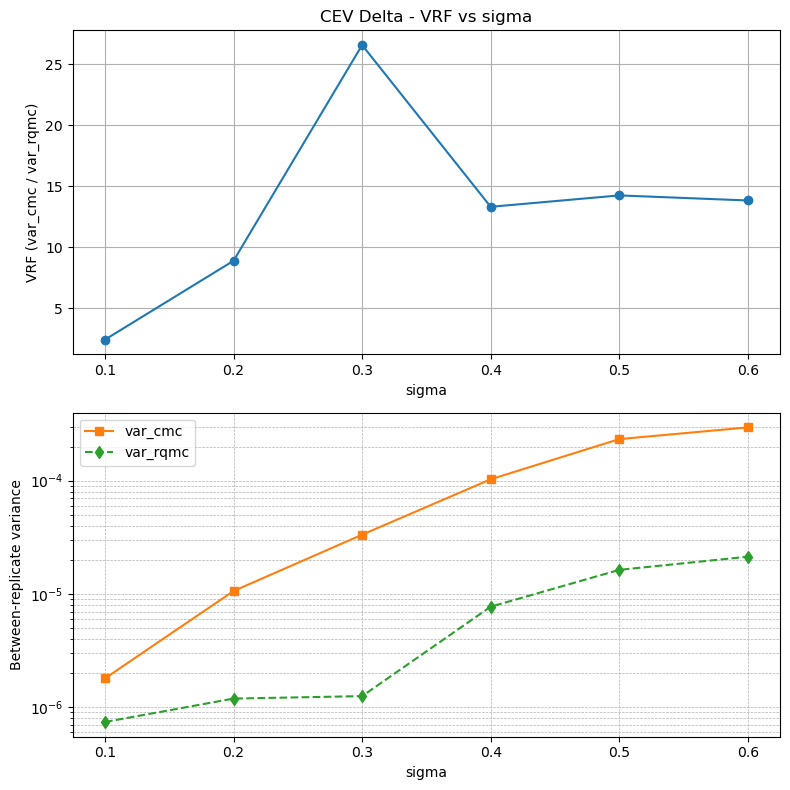

In [63]:
# VRF for Delta vs sigma
params = {'S0': 100, 'K': 100, 'r': 0.05, 'sigma': 0.3, 'gamma': 1.2, 'T': 1.0, 'M': 252, 'base_seed': 42}
sigmas = [0.1,0.2, 0.3, 0.4, 0.5, 0.6]
# NOTE: these runs can be expensive. Reduce N and n_batches for quick tests.
vrf_delta_sigma = lib.vrf_greek_vs_param(params, 'sigma', sigmas, N=2**14, n_batches=32, greek='delta')
lib.plot_vrf_vs_param(vrf_delta_sigma, title_prefix='CEV')

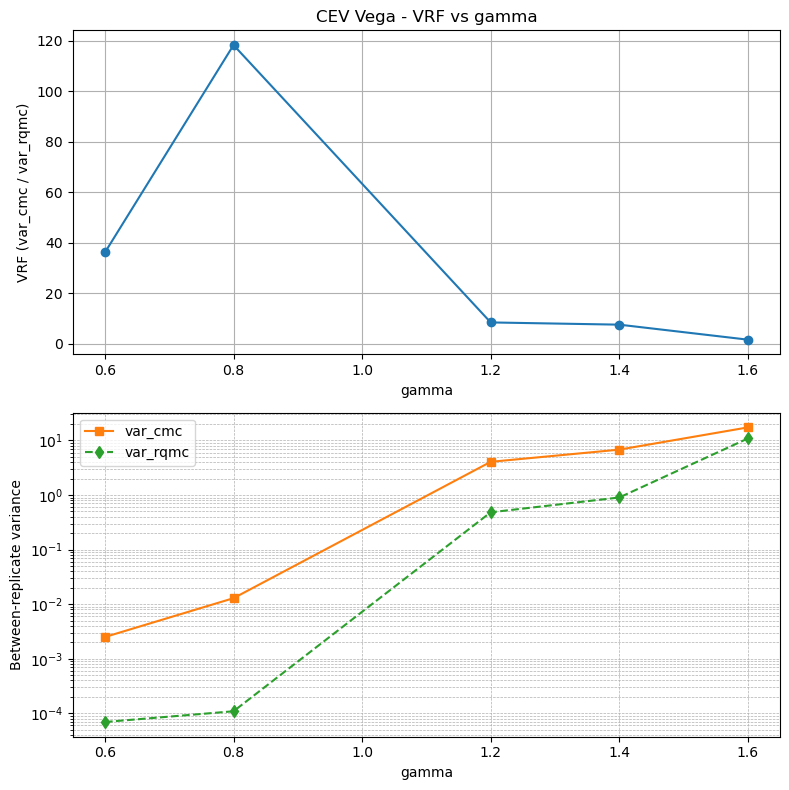

In [ ]:
# VRF for Vega vs gamma
gammas = [0.6, 0.8, 1.2, 1.4, 1.6]
vrf_vega_gamma = lib.vrf_greek_vs_param(params, 'gamma', gammas, N=2**14, n_batches=32, greek='vega')
lib.plot_vrf_vs_param(vrf_vega_gamma, title_prefix='CEV')

## Quick smoke-test (low cost)
The cell below runs a very small VRF smoke-test to validate the new helpers without heavy computation.

Running multi-method VRF (Delta vs sigma) with N= 16384  n_batches= 32


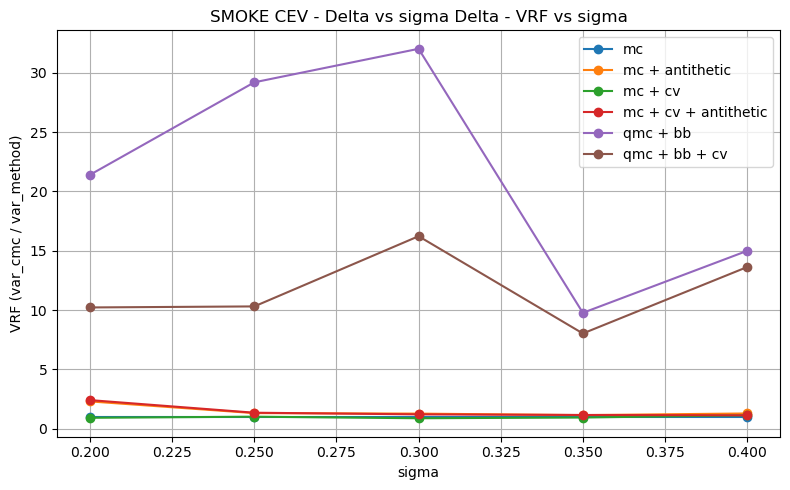

In [72]:
# Quick smoke-test for VRF helpers (low-cost)
import lib
params = {'S0':100, 'K':100, 'r':0.05, 'sigma':0.3, 'gamma':1.2, 'T':1.0, 'M':252, 'base_seed':42}
# Use tiny N and few batches for a fast smoke test
N = 2**14
n_batches = 32
sigmas = [0.2, 0.25, 0.3, 0.35,0.4]
print('Running multi-method VRF (Delta vs sigma) with N=', N, ' n_batches=', n_batches)
try:
    # Run multi-method VRF sweep. This computes per-method between-replicate variances
    # and VRF relative to CMC. The function defaults to a sensible set of methods
    res_multi = lib.vrf_greek_vs_param_all(params, 'sigma', sigmas, N=N, n_batches=n_batches, greek='delta')
    # Plot VRF vs sigma for all methods (VRF is computed relative to CMC)
    lib.plot_vrf_vs_param_methods(res_multi, title_prefix='SMOKE CEV - Delta vs sigma')
except Exception as e:
    print('Error during vrf_greek_vs_param_all (delta vs sigma) smoke test:', e)

# Optional: small multi-method smoke test for Vega vs gamma (kept for completeness)
#gammas = [0.8, 1.0]
#print('Running multi-method VRF (Vega vs gamma) with N=', N, ' n_batches=', n_batches)
#try:
#    res_all = lib.vrf_greek_vs_param_all(params, 'gamma', gammas, N=N, n_batches=n_batches, greek='vega')
#    lib.plot_vrf_vs_param_methods(res_all, title_prefix='SMOKE CEV - Vega vs gamma')
#except Exception as e:
#    print('Error during vrf_greek_vs_param_all (vega vs gamma) smoke test:', e)

# End of smoke-test cell